# 14 · Ablaciones, bagging de U y cierre

Paso 35. Se comparan conjuntos incrementales de geología, relieve, elementos guía, Au, hidrología y proporciones geoquímicas con RF de parámetros fijos. Usan exactamente los mismos folds, soporte y muestra por fold. Son contrastes exploratorios; no se selecciona una variante por su test externo.

In [1]:
from pathlib import Path
import sys, importlib
import pandas as pd
from IPython.display import display
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'src/geoau/training.py').is_file())
if str(ROOT/'src') not in sys.path: sys.path.insert(0, str(ROOT/'src'))
from geoau import training as tr
from geoau import evaluation as ev
importlib.reload(tr)

RUN = tr.current_run(ROOT)
sensitivity = tr.run_sensitivity(ROOT, RUN)
display(sensitivity)

Ablaciones y PU: outer_00


Ablaciones y PU: outer_01


Ablaciones y PU: outer_02


Ablaciones y PU: outer_03


Ablaciones y PU: outer_04


,experiment,kind,split_id,fit_seconds,train_P,train_U,rss_after_fit_mb,sample_path,sample_sha256,cells,...,positive_unit,recovery_at_01,area_fraction_01,recovery_at_05,area_fraction_05,recovery_at_10,area_fraction_10,average_precision_PU,roc_auc_PU,predict_seconds
0,geology,fixed_ablation,outer_00,0.919773,378.0,1134.0,1010.234375,C:/Users/Lenovo/Desktop/PROYECTO IA/Proyecto C...,13a4f149ad43a194431129aaf6f3aad4697ffa3953b6a0...,67947,...,candidate_cell,0.047619,0.009994,0.291005,0.049997,0.650794,0.099995,0.092026,0.870356,1.242175
1,geology_terrain,fixed_ablation,outer_00,0.712887,378.0,1134.0,734.105469,C:/Users/Lenovo/Desktop/PROYECTO IA/Proyecto C...,13a4f149ad43a194431129aaf6f3aad4697ffa3953b6a0...,67947,...,candidate_cell,0.031746,0.009994,0.285714,0.049997,0.629630,0.099995,0.086835,0.860151,1.304952
2,geology_terrain_pathfinders,fixed_ablation,outer_00,0.688385,378.0,1134.0,741.414062,C:/Users/Lenovo/Desktop/PROYECTO IA/Proyecto C...,13a4f149ad43a194431129aaf6f3aad4697ffa3953b6a0...,67947,...,candidate_cell,0.063492,0.009994,0.248677,0.049997,0.640212,0.099995,0.089355,0.868219,1.649591
3,geology_terrain_geo4,fixed_ablation,outer_00,0.733228,378.0,1134.0,746.414062,C:/Users/Lenovo/Desktop/PROYECTO IA/Proyecto C...,13a4f149ad43a194431129aaf6f3aad4697ffa3953b6a0...,67947,...,candidate_cell,0.068783,0.009994,0.301587,0.049997,0.708995,0.099995,0.097341,0.879002,1.774772
4,geology_terrain_geo4_hydro,fixed_ablation,outer_00,0.713584,378.0,1134.0,744.851562,C:/Users/Lenovo/Desktop/PROYECTO IA/Proyecto C...,13a4f149ad43a194431129aaf6f3aad4697ffa3953b6a0...,67947,...,candidate_cell,0.068783,0.009994,0.359788,0.049997,0.708995,0.099995,0.104641,0.889460,1.779169
5,geo4_proportions,fixed_ablation,outer_00,0.824996,378.0,1134.0,748.253906,C:/Users/Lenovo/Desktop/PROYECTO IA/Proyecto C...,13a4f149ad43a194431129aaf6f3aad4697ffa3953b6a0...,67947,...,candidate_cell,0.074074,0.009994,0.365079,0.049997,0.724868,0.099995,0.112020,0.891147,1.536474
6,pu_bagging,background_sensitivity,outer_00,NaN,NaN,NaN,NaN,NaN,NaN,67947,...,candidate_cell,0.068783,0.009994,0.402116,0.049997,0.756614,0.099995,0.123380,0.901648,NaN
7,geology,fixed_ablation,outer_01,0.719274,498.0,1494.0,779.398438,C:/Users/Lenovo/Desktop/PROYECTO IA/Proyecto C...,3b85953b9b493fe24b3ed5150486ab0adec24bbeb48b14...,85001,...,candidate_cell,0.398148,0.009988,0.638889,0.049994,0.787037,0.099995,0.210547,0.938826,1.597151
8,geology_terrain,fixed_ablation,outer_01,0.789403,498.0,1494.0,756.914062,C:/Users/Lenovo/Desktop/PROYECTO IA/Proyecto C...,3b85953b9b493fe24b3ed5150486ab0adec24bbeb48b14...,85001,...,candidate_cell,0.416667,0.009988,0.629630,0.049996,0.805556,0.099995,0.218989,0.934050,1.706436
9,geology_terrain_pathfinders,fixed_ablation,outer_01,0.734858,498.0,1494.0,763.101562,C:/Users/Lenovo/Desktop/PROYECTO IA/Proyecto C...,3b85953b9b493fe24b3ed5150486ab0adec24bbeb48b14...,85001,...,candidate_cell,0.425926,0.009988,0.694444,0.049997,0.824074,0.099997,0.209020,0.951228,2.241332


## Variación de fondo
El bagging promedia tres RF ajustados con las realizaciones U de E. Conserva P, los parámetros seleccionados internamente y el territorio test. La dispersión incluye variación de fondo y semilla del estimador; no es un intervalo de confianza de la mineralización. No se calibra contra U como si fueran ausencias verificadas.

In [2]:
control = tr.finish_run(ROOT, RUN)
display(control)
display(pd.read_csv(RUN/'nested_procedure_metrics.csv'))
display(ev.read_json(RUN/'pending_experiments.json'))

{'estado_ejecucion': 'completada',
 'mode': 'diagnostic',
 'scientific_training_allowed': False,
 'scientific_validation_complete': False,
 'prediction_allowed': False,
 'production_allowed': False,
 'outer_folds': 5,
 'search_trials_per_family': 3,
 'families': ['logistic', 'random_forest', 'extra_trees', 'hist_boosting'],
 'fitted_model_files': 60,
 'reason': 'Ensayo con candidatos y predictores no aprobados; revisar B/D/E antes de validación científica.'}

,outer_split,candidate_id,family,ratio,params,mean_inner_recovery_at_05,cells,observed_P_cells,positive_unit,recovery_at_01,area_fraction_01,recovery_at_05,area_fraction_05,recovery_at_10,area_fraction_10,average_precision_PU,roc_auc_PU
0,outer_00,random_forest_02,random_forest,10,"{'n_estimators': 500, 'min_samples_leaf': 2, '...",0.500571,67947,189,candidate_cell,0.084656,0.009994,0.449735,0.049997,0.767196,0.099995,0.126035,0.901745
1,outer_01,random_forest_02,random_forest,10,"{'n_estimators': 500, 'min_samples_leaf': 2, '...",0.551527,85001,108,candidate_cell,0.398148,0.010000,0.666667,0.049996,0.796296,0.099995,0.239897,0.945757
2,outer_02,random_forest_00,random_forest,3,"{'n_estimators': 500, 'min_samples_leaf': 5, '...",0.639245,93064,123,candidate_cell,0.276423,0.009993,0.609756,0.049995,0.821138,0.099992,0.220387,0.940930
3,outer_03,random_forest_02,random_forest,10,"{'n_estimators': 500, 'min_samples_leaf': 2, '...",0.573157,72474,65,candidate_cell,0.307692,0.009990,0.415385,0.049993,0.415385,0.099997,0.111403,0.869232
4,outer_04,extra_trees_02,extra_trees,10,"{'n_estimators': 500, 'min_samples_leaf': 10, ...",0.489132,82001,158,candidate_cell,0.120253,0.009988,0.379747,0.049989,0.563291,0.099989,0.092945,0.810354


{'500m_and_buffers': 'Requiere nuevas ejecuciones C/D/E; no interpolar ni alterar folds sellados.',
 'geophysics_and_alluvial': 'No hay bloques cuantitativos/cuencas aprobados en D.',
 'label_confidence': 'Requiere revisión B y propagación hasta E.',
 'observation_effort': 'Fuente verificable ausente; no se simula.',
 'extended_models': 'XGBoost/LightGBM/CatBoost y KNN/SVM son ampliaciones opcionales.',
 'larger_search': 'Piloto de 3 candidatos por familia; 20–30 mediante search_trials tras revisar protocolo.',
 'pu_interpretation': 'Variación de fondo y semilla del estimador; no intervalo de confianza de mineralización.'}

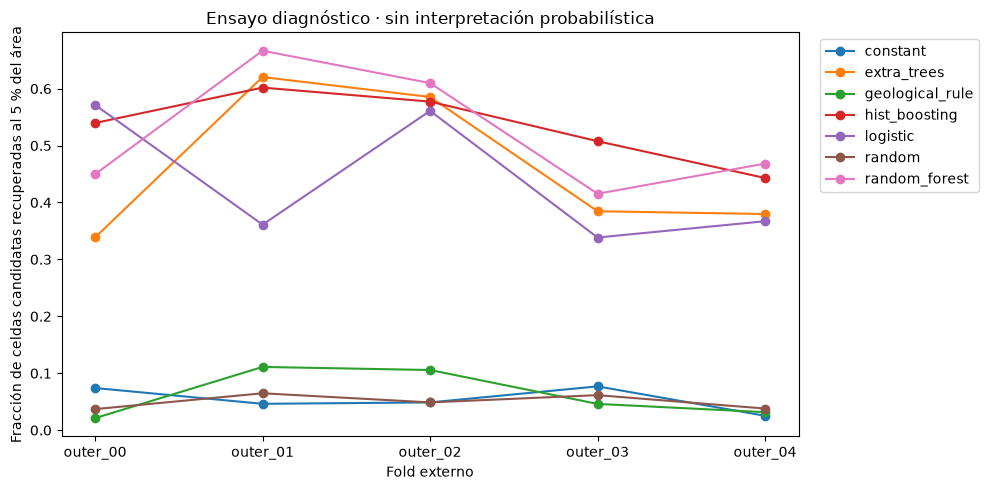

In [3]:
import matplotlib.pyplot as plt
table = pd.read_csv(RUN/'comparison_by_fold.csv')
fig, ax = plt.subplots(figsize=(10, 5))
for name, part in table.groupby('family'):
    ax.plot(part.split_id, part.recovery_at_05, marker='o', label=name)
ax.set(ylabel='Fracción de celdas candidatas recuperadas al 5 % del área',
       xlabel='Fold externo', title='Ensayo diagnóstico · sin interpretación probabilística')
ax.legend(bbox_to_anchor=(1.02, 1)); fig.tight_layout(); plt.show()
ev.verify(RUN, ev.read_json(RUN/'outputs_manifest.json'))

## Continuación
La resolución de 500 m, cambios de buffers/etiquetas y geofísica requieren nuevas entradas verificadas y nuevas ejecuciones anteriores. No se simulan capas ausentes. El cierre técnico de F no aprueba científicamente B/D/E ni sustituye la evaluación G. La reserva sigue cerrada.